In [20]:
import pandas as pd


In [28]:
# ── 1. Load ───────────────────────────────────────────────────────────────────
df = pd.read_csv("/zhome/d0/a/221493/thesis/notebooks/expanded_metadata_all_train_valid.csv")
print(f"Dataset shape: {df.shape}")

Dataset shape: (16148, 38)


### Remove columns with excessive Missing values

In [31]:
# ── 2. Drop columns with >50% missing ─────────────────────────────────────────
missing_pct = df.isna().mean() * 100
df = df[missing_pct[missing_pct < 50].index]
print(f"After dropping high-missing columns: {df.shape}")

After dropping high-missing columns: (16148, 24)


In [32]:
# ── 2. Drop columns with >50% missing ─────────────────────────────────────────
missing_pct = df.isna().mean() * 100
df = df[missing_pct[missing_pct < 50].index]
print(f"After dropping high-missing columns: {df.shape}")

After dropping high-missing columns: (16148, 24)


In [34]:
# ── 3. Treat zeros as NaN for exposure/technical columns ──────────────────────
# Zero is physically meaningless for these fields (Agfa stores 0 as sentinel)
zero_as_nan_cols = ["KVP", "Exposure", "RelativeXRayExposure"]
for col in zero_as_nan_cols:
    if col in df.columns:
        n_zeros = (df[col] == 0).sum()
        df[col] = df[col].replace(0, float("nan"))
        print(f"  {col}: replaced {n_zeros} zeros with NaN")

  KVP: replaced 4175 zeros with NaN
  Exposure: replaced 4175 zeros with NaN
  RelativeXRayExposure: replaced 0 zeros with NaN


### Stadardize manufacturer names 

In [35]:
# ── 4. Standardise Manufacturer ───────────────────────────────────────────────
manufacturer_mapping = {
    "Agfa": "AGFA",
    "Agfa-Gevaert AG": "AGFA",
    "GE MEDICAL SYSTEMS": "GE",
    '"GE Healthcare"': "GE",
    "GE Healthcare": "GE",
}
df["Manufacturer"] = df["Manufacturer"].replace(manufacturer_mapping)
print("\nManufacturer counts:\n", df["Manufacturer"].value_counts())




Manufacturer counts:
 Manufacturer
AGFA      11083
GE         5061
Varian        4
Name: count, dtype: int64


In [36]:
# ── 5. Split into train / valid ────────────────────────────────────────────────
train = df[df["split"] == "train"].copy()
valid = df[df["split"] == "valid"].copy()
print(f"\nTrain: {len(train)}  |  Valid: {len(valid)}")


Train: 16141  |  Valid: 7


In [37]:
# ── 6. Summary statistics (train only) ────────────────────────────────────────
META_COLS = ["Manufacturer", "ViewPosition", "PhotometricInterpretation",
             "BitsStored", "RescaleType", "BurnedInAnnotation"]
NUM_COLS  = ["RelativeXRayExposure", "KVP", "Exposure",
             "Rows", "Columns", "BitsAllocated"]

print("\n── Categorical counts (train) ──")
for col in META_COLS:
    if col in train.columns:
        print(f"\n{col}:\n{train[col].value_counts()}")

print("\n── Numeric summary (train) ──")
print(train[NUM_COLS].describe().round(2))




── Categorical counts (train) ──

Manufacturer:
Manufacturer
AGFA      11076
GE         5061
Varian        4
Name: count, dtype: int64

ViewPosition:
ViewPosition
AP    10363
PA     2979
LL     2781
RL       18
Name: count, dtype: int64

PhotometricInterpretation:
PhotometricInterpretation
MONOCHROME1    11078
MONOCHROME2     5063
Name: count, dtype: int64

BitsStored:
BitsStored
12    9904
14    5061
15    1176
Name: count, dtype: int64

RescaleType:
RescaleType
LOG_E REL    9836
US           5061
P-VALUES     1181
OD             32
OD REL         31
Name: count, dtype: int64

BurnedInAnnotation:
BurnedInAnnotation
NO    11972
Name: count, dtype: int64

── Numeric summary (train) ──
       RelativeXRayExposure      KVP  Exposure      Rows   Columns  \
count              11057.00  5882.00   5882.00  16141.00  16141.00   
mean                 438.09   111.65     11.05   2247.30   2552.92   
std                 1110.68    10.19     23.82    286.48    494.96   
min                    1.0

In [42]:
# Save acquisition dataset for later use
train.to_csv("/zhome/d0/a/221493/thesis/notebooks/acquisition_metadata_train.csv", index=False)
valid.to_csv("/zhome/d0/a/221493/thesis/notebooks/acquisition_metadata_valid.csv", index=False)

### Data Visualization

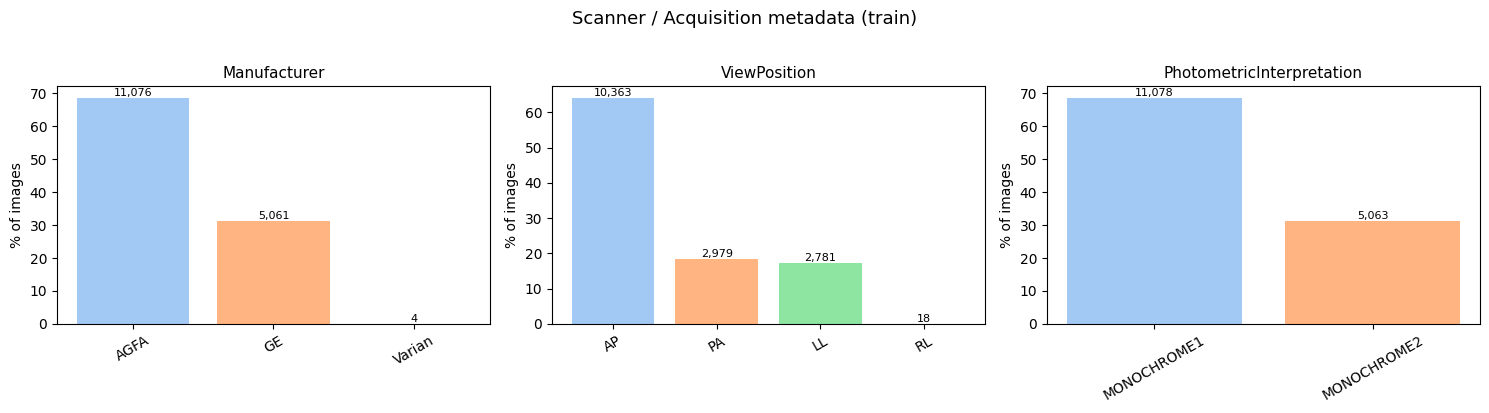

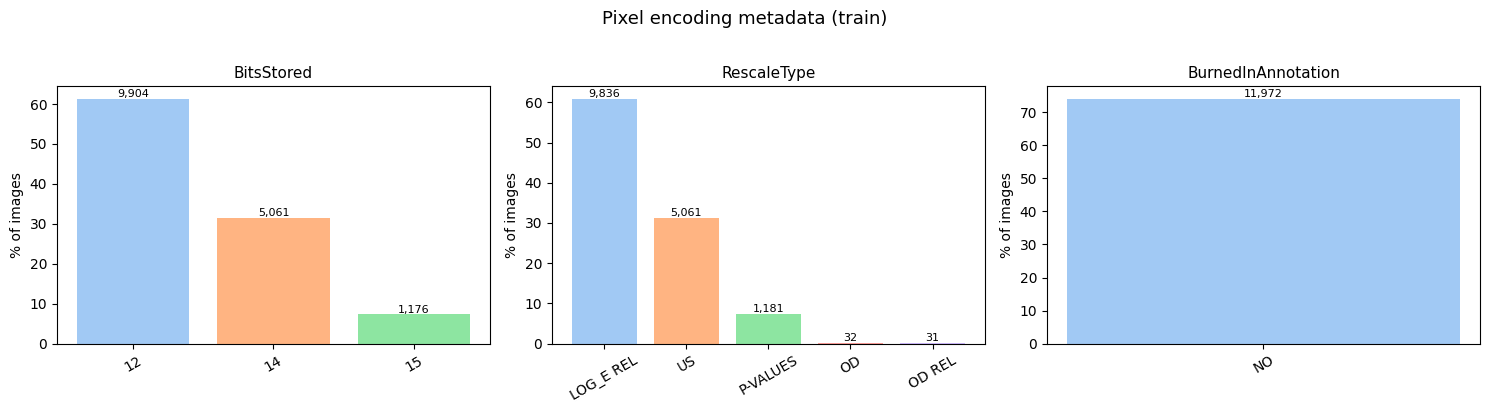

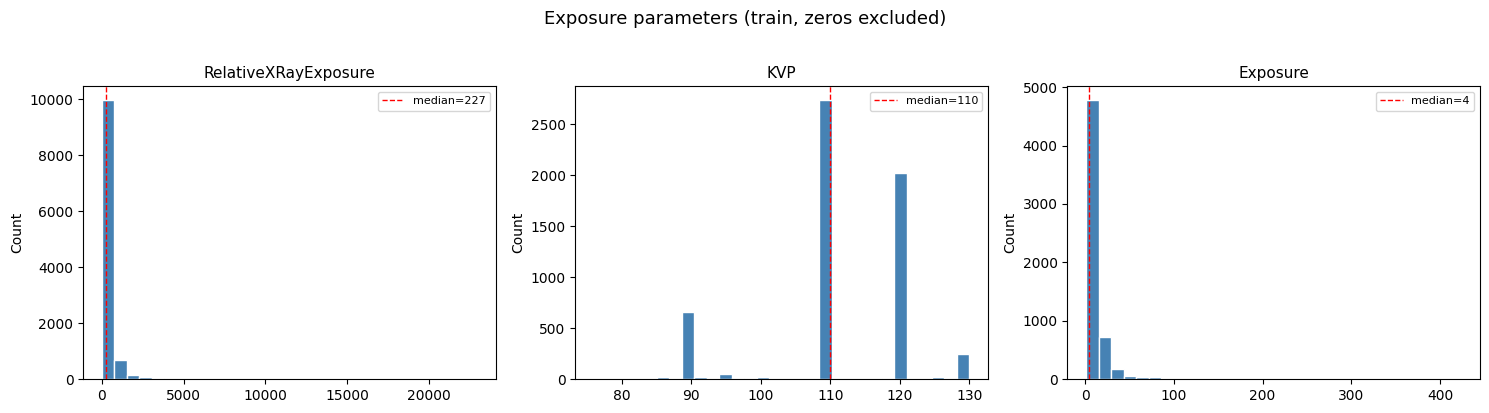

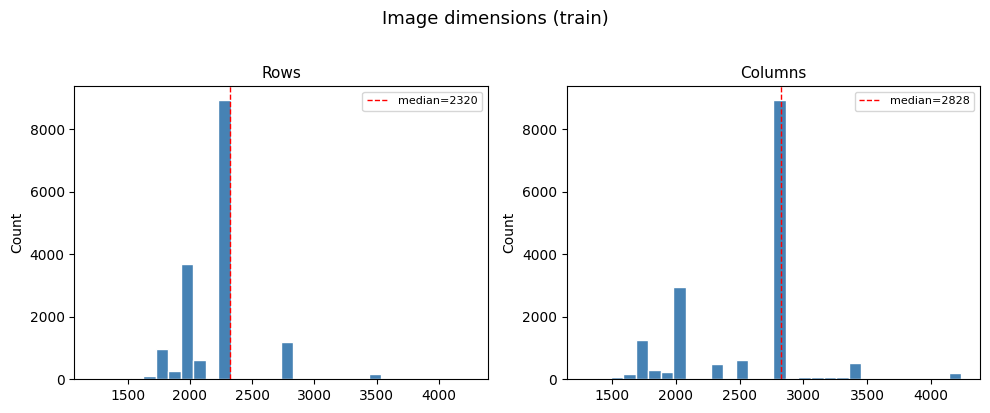


Manufacturer × ViewPosition (% row, train):
 ViewPosition    AP    LL    PA   RL
Manufacturer                       
AGFA          93.1   1.7   5.1  0.0
GE             0.9  51.1  47.6  0.3
Varian         0.0  50.0  50.0  0.0

Manufacturer × PhotometricInterpretation (% row, train):
 PhotometricInterpretation  MONOCHROME1  MONOCHROME2
Manufacturer                                       
AGFA                             100.0          0.0
GE                                 0.0        100.0
Varian                             0.0        100.0


In [38]:
import matplotlib.pyplot as plt
# ── 7. Visualise ──────────────────────────────────────────────────────────────
# Separate plots per category keeps things readable

def plot_categoricals(data, cols, title_prefix=""):
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        if col not in data.columns:
            ax.set_visible(False)
            continue
        counts = data[col].value_counts()
        pct = counts / len(data) * 100
        bars = ax.bar(counts.index.astype(str), pct, color=sns.color_palette("pastel"))
        ax.set_title(f"{col}", fontsize=11)
        ax.set_ylabel("% of images")
        ax.tick_params(axis="x", rotation=30)
        for bar, (cnt, p) in zip(bars, zip(counts, pct)):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5, f"{cnt:,}", ha="center", fontsize=8)
    plt.suptitle(title_prefix, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_numerics(data, cols, title_prefix=""):
    valid_cols = [c for c in cols if c in data.columns]
    n = len(valid_cols)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, valid_cols):
        series = data[col].dropna()
        ax.hist(series, bins=30, color="steelblue", edgecolor="white")
        ax.set_title(f"{col}", fontsize=11)
        ax.set_ylabel("Count")
        ax.axvline(series.median(), color="red", linestyle="--", linewidth=1,
                   label=f"median={series.median():.0f}")
        ax.legend(fontsize=8)
    plt.suptitle(title_prefix, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


# Categorical plots
plot_categoricals(train, ["Manufacturer", "ViewPosition", "PhotometricInterpretation"],
                  "Scanner / Acquisition metadata (train)")
plot_categoricals(train, ["BitsStored", "RescaleType", "BurnedInAnnotation"],
                  "Pixel encoding metadata (train)")

# Numeric plots
plot_numerics(train, ["RelativeXRayExposure", "KVP", "Exposure"],
              "Exposure parameters (train, zeros excluded)")
plot_numerics(train, ["Rows", "Columns"],
              "Image dimensions (train)")

# ── 8. Cross-tab: Manufacturer × ViewPosition ─────────────────────────────────
ct = pd.crosstab(train["Manufacturer"], train["ViewPosition"], normalize="index").round(3) * 100
print("\nManufacturer × ViewPosition (% row, train):\n", ct)

# ── 9. Manufacturer × PhotometricInterpretation ───────────────────────────────
ct2 = pd.crosstab(train["Manufacturer"], train["PhotometricInterpretation"],
                  normalize="index").round(3) * 100
print("\nManufacturer × PhotometricInterpretation (% row, train):\n", ct2)

# ─ Why this matters: MONOCHROME1 and MONOCHROME2 have inverted pixel polarity.
# If your model mixes them without normalisation it will see some X-rays "flipped".

